### Аналіз Titanic Dataset

Titanic Dataset містить дані про пасажирів корабля Titanic. Кожен рядок описує одного пасажира через демографічні характеристики, клас квитка, родинні зв'язки, вартість квитка та факт виживання.

#### Практична задача

За характеристиками пасажира передбачити, чи вижив він.

#### Dataset

`https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv`

#### Опис колонок

| Колонка | Що означає | Тип даних | Чи корисна для ML |
|---|---|---|---|
| `survived` | чи вижив пасажир: 0 - ні, 1 - так | число | так, але як цільова ознака |
| `pclass` | клас квитка: 1, 2 або 3 | число | так, це вхідна ознака |
| `sex` | стать пасажира | категорія | так, це вхідна ознака |
| `age` | вік пасажира | число | так, це вхідна ознака |
| `sibsp` | кількість братів, сестер або подружжя на борту | число | так, це вхідна ознака |
| `parch` | кількість батьків або дітей на борту | число | так, це вхідна ознака |
| `fare` | вартість квитка | число | так, це вхідна ознака |
| `embarked` | порт посадки | категорія | так, це вхідна ознака |
| `class` | клас квитка текстом | категорія | так, але дублює `pclass` |
| `who` | група пасажира: man, woman або child | категорія | так, це вхідна ознака |
| `adult_male` | чи є пасажир дорослим чоловіком | логічний | так, це вхідна ознака |
| `deck` | палуба каюти | категорія | можливо, але має багато пропусків |
| `embark_town` | місто посадки | категорія | так, але дублює `embarked` |
| `alive` | чи вижив пасажир текстом | категорія | так, але дублює цільову `survived` |
| `alone` | чи подорожував пасажир сам | логічний | так, це вхідна ознака |

In [1]:
import numpy as np
import pandas as pd

In [2]:
titanic_df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')

In [3]:
titanic_df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic_df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
titanic_df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanic_df.mode()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,24.0,0,0,8.05,S,Third,man,True,C,Southampton,no,True


In [7]:
titanic_df['age'].mode()

0    24.0
Name: age, dtype: float64

In [8]:
df = pd.DataFrame({
    'age': [10, 10, 10, 11, 19, 19, 19, 12, 35, 40, 51]
})
df['age'].mode()

0    10
1    19
Name: age, dtype: int64

In [9]:
titanic_df['age'].value_counts()

age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [10]:
titanic_df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* percentile: 0.01, 0.02, ..., 0.98, 0.99
* quartile: 0-25%, 25-50%, 50-75%, 75-100%
* quantile
** 25% - стільки значень менші ніж 0.25 quantile
** 50% - стільки значень менші ніж 0.50 quantile (median)

In [11]:
titanic_df['age'].quantile(0.88)   # 88%

np.float64(48.0)

In [12]:
titanic_df['age'].std()

np.float64(14.526497332334042)

<Axes: title={'center': 'age'}, xlabel='pclass'>

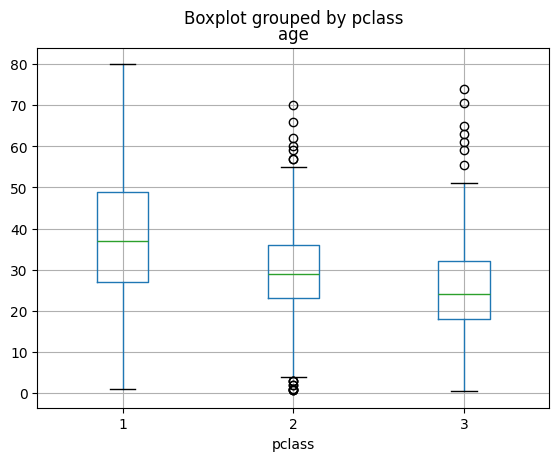

In [13]:
titanic_df.boxplot(column='age', by='pclass')

<Axes: >

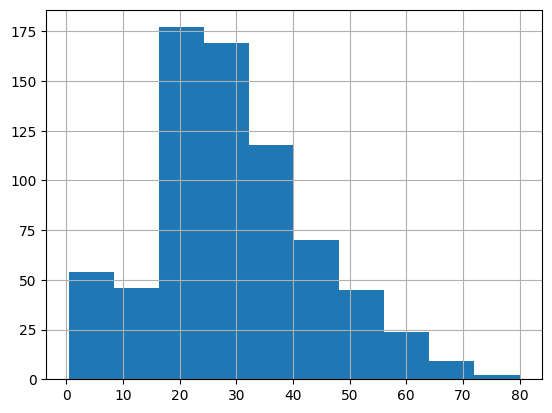

In [14]:
titanic_df['age'].hist(bins=10)

In [15]:
cov_matrix = titanic_df[['age', 'fare']].cov()
cov_matrix

,age,fare
age,211.019125,73.849030
fare,73.849030,2469.436846


In [19]:
import matplotlib.pyplot as plt
import numpy as np

In [20]:
plt.style.use('default')

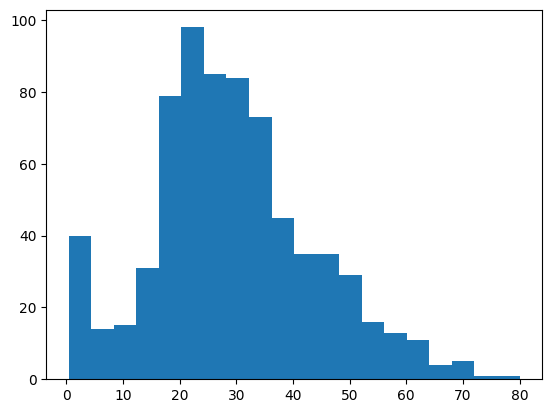

In [24]:
plt.hist(titanic_df['age'], bins=20)
plt.show()